Imports

In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import ast
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import RandomOverSampler




Load data

In [65]:
DEMO_J = pd.read_sas("./raw/2017_2018/DEMO_J.XPT")
BPX_J = pd.read_sas("./raw/2017_2018/BPX_J.XPT")
BMX_J = pd.read_sas("./raw/2017_2018/BMX_J.XPT")
CBC_J = pd.read_sas("./raw/2017_2018/CBC_J.XPT")
FERTIN_J = pd.read_sas("./raw/2017_2018/FERTIN_J.XPT")
VID_J = pd.read_sas("./raw/2017_2018/VID_J.XPT")
HSCRP_J = pd.read_sas("./raw/2017_2018/HSCRP_J.XPT")
BIOPRO_J = pd.read_sas("./raw/2017_2018/BIOPRO_J.XPT")
PAQ_J = pd.read_sas("./raw/2017_2018/PAQ_J.XPT")
ALQ_J = pd.read_sas("./raw/2017_2018/ALQ_J.XPT")
SMQ_J = pd.read_sas("./raw/2017_2018/SMQ_J.XPT")
SLQ_J = pd.read_sas("./raw/2017_2018/SLQ_J.XPT")
DUQ_J = pd.read_sas("./raw/2017_2018/DUQ_J.XPT")
WHQ_J = pd.read_sas("./raw/2017_2018/WHQ_J.XPT")
SMQRTU_J = pd.read_sas("./raw/2017_2018/SMQRTU_J.XPT")
DPQ_J = pd.read_sas("./raw/2017_2018/DPQ_J.XPT")

data_frames = {
    'DEMO': DEMO_J,
    'BPX': BPX_J,
    'BMX': BMX_J,
    'CBC': CBC_J,
    'FERTIN': FERTIN_J,
    'VID': VID_J,
    'HSCRP': HSCRP_J,
    'BIOPRO': BIOPRO_J,
    'PAQ': PAQ_J,
    'ALQ': ALQ_J,
    'SMQ': SMQ_J,
    'SMQRTU': SMQRTU_J,
    'DPQ': DPQ_J,
    'SLQ': SLQ_J,
    'DUQ': DUQ_J,
    'WHQ': WHQ_J
}



In [66]:
# codebook includes a description of each data file and variable, as well as a first pass at selecting model input and output variables

codebook = pd.read_csv('./raw/2017_2018/codebook_2017_2018.csv')
codebook.head()

,Variable Name,Variable Description,Data File Name,Data File Description,Begin Year,EndYear,Component,Use Constraints,Model Feature,Model Output,Column Alias,OHE,Value Encoding,Missing Data Remap?,Remap Value,Fill Zeros,Numeric
0,AIALANGA,Language of the MEC ACASI Interview Instrument,DEMO_J,Demographic Variables and Sample Weights,2017,2018,Demographics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,DMDBORN4,In what country {were you/was SP} born?,DEMO_J,Demographic Variables and Sample Weights,2017,2018,Demographics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,DMDCITZN,{Are you/Is SP} a citizen of the United States...,DEMO_J,Demographic Variables and Sample Weights,2017,2018,Demographics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,DMDEDUC2,What is the highest grade or level of school {...,DEMO_J,Demographic Variables and Sample Weights,2017,2018,Demographics,NaN,True,NaN,max_education,True,"{ 1: ""less than 9th grade"", 2: ""9-11th grade (...",NaN,NaN,NaN,NaN
4,DMDEDUC3,What is the highest grade or level of school {...,DEMO_J,Demographic Variables and Sample Weights,2017,2018,Demographics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [67]:
for name, val in data_frames.items():
    print(codebook[codebook['Data File Name'] == f"{name}_J"]['Data File Description'].iloc[0])
    print('Shape: ', val.shape)
    print('n patients: ', val['SEQN'].nunique())
    print()

Demographic Variables and Sample Weights
Shape:  (9254, 46)
n patients:  9254

Blood Pressure 
Shape:  (8704, 21)
n patients:  8704

Body Measures
Shape:  (8704, 21)
n patients:  8704

Complete Blood Count with 5-Part Differential
Shape:  (8366, 22)
n patients:  8366

Ferritin 
Shape:  (7332, 3)
n patients:  7332

Vitamin D 
Shape:  (8366, 9)
n patients:  8366

High-Sensitivity C-Reactive Protein
Shape:  (8366, 3)
n patients:  8366

Standard Biochemistry Profile
Shape:  (6401, 41)
n patients:  6401

Physical Activity
Shape:  (5856, 17)
n patients:  5856

Alcohol Use
Shape:  (5533, 10)
n patients:  5533

Smoking - Cigarette Use
Shape:  (6724, 37)
n patients:  6724

Smoking - Recent Tobacco Use
Shape:  (6401, 27)
n patients:  6401

Mental Health - Depression Screener
Shape:  (5533, 11)
n patients:  5533

Sleep Disorders
Shape:  (6161, 11)
n patients:  6161

Drug Use
Shape:  (4572, 41)
n patients:  4572

Weight History
Shape:  (6161, 37)
n patients:  6161



In [68]:
from functools import reduce

# Prefix non-SEQN columns to avoid name collisions, then outer-merge all on SEQN
dfs = [df.rename(columns=lambda c: c if c == 'SEQN' else f"{name}_{c}") for name, df in data_frames.items()]
merged = reduce(lambda left, right: pd.merge(left, right, on='SEQN', how='outer'), dfs)
merged = merged.replace(5.397605346934028e-79, 0) # weird things happening when value = 0 in sas files

print(merged.shape)
print(merged['SEQN'].nunique())

(9254, 342)
9254


In [69]:
# select columns from `merged` where codebook marks them as model feature or model output
def _find_col(codebook, keywords):
    for c in codebook.columns:
        low = c.lower()
        if all(k in low for k in keywords):
            return c
    for c in codebook.columns:
        low = c.lower()
        if any(k in low for k in keywords):
            return c
    return None

var_col = _find_col(codebook, ['var']) or _find_col(codebook, ['name']) or _find_col(codebook, ['column'])
feat_col = _find_col(codebook, ['model','feature']) or _find_col(codebook, ['feature'])
out_col = _find_col(codebook, ['model','output']) or _find_col(codebook, ['output'])
dfname_col = _find_col(codebook, ['data file']) or _find_col(codebook, ['file'])

if var_col is None:
    raise ValueError("Couldn't locate variable name column in codebook.")

# build boolean mask for rows flagged as feature or output (accepts True/False, 1/0, 'true'/'1', etc.)
masks = []
for col in (feat_col, out_col):
    if col is not None:
        s = codebook[col].astype(str).str.lower()
        masks.append(s.isin(['1','true','t','y','yes'] ) | (pd.to_numeric(codebook[col], errors='coerce')>0).fillna(False))
if not masks:
    raise ValueError("Couldn't find feature/output flag columns in codebook.")
mask = masks[0]
for m in masks[1:]:
    mask = mask | m

selected_rows = codebook.loc[mask].dropna(subset=[var_col])

# construct merged column names: prefix from data file name (e.g. 'WHQ_J' -> 'WHQ') + '_' + variable
def merged_col_name(row):
    var = str(row[var_col]).strip()
    if var.upper() == 'SEQN':
        return 'SEQN'
    dfname = ''
    if dfname_col and pd.notna(row.get(dfname_col)):
        dfname = str(row[dfname_col])
    prefix = dfname.replace('_J','').rstrip('_') if dfname else ''
    return f"{prefix}_{var}" if prefix else var

cols = [merged_col_name(r) for _, r in selected_rows.iterrows()]
cols = ['SEQN'] + [c for c in cols if c in merged.columns and c != 'SEQN']

merged_selected = merged[cols].copy()

# apply alias names from codebook (Column Alias) except for SEQN; ensure unique column names
alias_map = {}
used_aliases = set(merged_selected.columns)  # avoid collisions with existing names
for _, row in selected_rows.iterrows():
    col = merged_col_name(row)
    if col == 'SEQN' or col not in merged_selected.columns:
        continue
    alias = row.get('Column Alias')
    if pd.isna(alias):
        continue
    alias = str(alias).strip()
    if not alias or alias.upper() == 'SEQN':
        continue
    final_alias = alias
    i = 1
    while final_alias in used_aliases:
        final_alias = f"{alias}_{i}"
        i += 1
    alias_map[col] = final_alias
    used_aliases.add(final_alias)

if alias_map:
    merged_selected.rename(columns=alias_map, inplace=True)

merged_selected.shape

(9254, 87)

## Check outputs

How many participants completed all questions of the 2017/2018 depression screener? (model output)


In [70]:
output_cols = list(codebook[codebook['Model Output'] == True]['Column Alias'])
# output_cols = [f"DPQ_{col}" if not col.startswith("DPQ_") else col for col in output_cols]

merged_outputs = merged_selected[['SEQN'] + [col for col in output_cols if col in merged_selected.columns]]

# drop refusals and missing surveys
merged_outputs = merged_outputs[(merged_outputs[output_cols] <= 3).all(axis=1)]
merged_outputs.dropna(subset=output_cols, how='all').shape

(5068, 10)

What kind of distribution of scores are we working with? 

On interpretation of the PHQ-9: 
- On the PHQ-9 depression scale, a score of 10 or higher is generally considered "bad" (moderate to severe depression) and indicates a need for clinical treatment. Scores range from 0–27, with higher numbers indicating more severe symptoms: 10-14 (moderate), 15-19 (moderately severe), and 20+ (severe). 

        PHQ-9 Score Interpretation:
        0–4: Minimal or no depression
        5–9: Mild depression (support and education)
        10–14: Moderate depression (consider counseling/medication)
        15–19: Moderately severe depression (active treatment recommended)
        20–27: Severe depression (active treatment required)

In [71]:
# calculate sum of dpq scores
dpq_cols = [col for col in merged_outputs.columns if col.startswith("dpq_")]
merged_outputs["dpq_total"] = merged_outputs[dpq_cols].sum(axis=1)

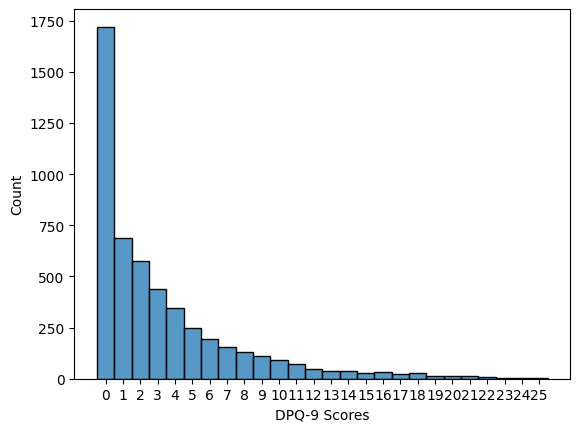

In [72]:
sns.histplot(merged_outputs['dpq_total'], discrete=True)
plt.xticks(np.arange(merged_outputs['dpq_total'].min(), merged_outputs['dpq_total'].max() + 1, 1))
plt.xlabel('DPQ-9 Scores')
plt.show()

In [73]:
# what about categories?

def remap_dpq_9(x):
    if x >= 0 and x <= 4:
        return "Minimal or no depression"
    if x >= 5 and x <= 9:
        return "Mild depression"
    if x >= 10 and x <= 14:
        return "Moderate depression"
    if x >= 15 and x <= 19:
        return "Moderately severe depression"
    if x >= 20:
        return "Severe depression"
    
merged_outputs["depression_category"] = merged_outputs["dpq_total"].apply(remap_dpq_9)
print(merged_outputs["depression_category"].value_counts())
print("")


# counts for if depression is of clinical concern (binary)
def remap_dpq_9_binary(x):
    if x >= 10:
        return True
    else:
        return False
    
merged_outputs["depression_binary"] = merged_outputs["dpq_total"].apply(remap_dpq_9_binary)
print(merged_outputs["depression_binary"].value_counts())
print(f"{len(merged_outputs[merged_outputs['depression_binary'] == True])/ len(merged_outputs) * 100:.2f}% of patients in set have depression of clinical concern.")

depression_category
Minimal or no depression        3772
Mild depression                  837
Moderate depression              292
Moderately severe depression     124
Severe depression                 43
Name: count, dtype: int64

depression_binary
False    4609
True      459
Name: count, dtype: int64
9.06% of patients in set have depression of clinical concern.


In [74]:
# combine depression outcomes to get 3-category depression severity 
def remap_severity(x):
    if x in ['Minimal or no depression']:
        return 0
    if x in ['Mild depression']:
        return 1
    if x in ['Moderate depression', 'Moderately severe depression', 'Severe depression']:
        return 2
    
merged_outputs["depression_severity"] = merged_outputs["depression_category"].apply(remap_severity)
print(merged_outputs["depression_severity"].value_counts())


depression_severity
0    3772
1     837
2     459
Name: count, dtype: int64


### Prepping data for EDA

In [75]:
# codebook reload for convenience
codebook = pd.read_csv('./raw/2017_2018/codebook_2017_2018.csv')

feature_cols = codebook[(codebook['Model Feature'] == True) & (codebook['Variable Name'] != 'SEQN')]['Column Alias'].values
feature_cols = np.insert(feature_cols, 0, 'SEQN')

# make a copy of data for model prep
df = merged_selected.copy()

# select feature columns
df = df[feature_cols]

In [76]:
# join outputs so that we select for patients who did the DPQ-9, and get our labels

outputs = merged_outputs.copy()

df = df.merge(outputs, on = 'SEQN')
df.shape

(5068, 91)

In [77]:
# Some questionnaire responses should be mapped to Null values
remap_null_cols = codebook[codebook['Missing Data Remap?'] == True]['Column Alias'].values

for col in remap_null_cols:
    remap_val = codebook[codebook['Column Alias'] == col]['Remap Value'].iloc[0]
    df[col] = df[col].replace(remap_val, np.nan)

In [78]:
# some questionnaire responses should have nulls mapped to zero
remap_zeros = codebook[codebook['Fill Zeros'] == True]['Column Alias'].values

for col in remap_zeros:
    df[col] = df[col].fillna(0)

In [79]:
# write this output to a parquet for EDA
df.to_parquet('compiled_data.parquet', compression='snappy')

In [80]:
df.head()

,SEQN,max_education,marital_status,income_poverty_ratio,gender,age,pregnancy_status,reported_race,2_year_interview_weight,2_year_mec_exam_weight,...,dpq_4,dpq_5,dpq_6,dpq_7,dpq_8,dpq_9,dpq_total,depression_category,depression_binary,depression_severity
0,93705.0,2.0,3.0,0.82,2.0,66.0,NaN,4.0,8614.571172,8338.419786,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Minimal or no depression,False,0
1,93706.0,NaN,NaN,NaN,1.0,18.0,NaN,6.0,8548.632619,8723.439814,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Minimal or no depression,False,0
2,93708.0,1.0,1.0,1.63,2.0,66.0,NaN,6.0,13329.450589,14372.488765,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Minimal or no depression,False,0
3,93711.0,5.0,1.0,5.00,1.0,56.0,NaN,6.0,11178.260106,12390.919724,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Minimal or no depression,False,0
4,93712.0,NaN,NaN,0.76,1.0,18.0,NaN,1.0,29040.496558,30336.654325,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Minimal or no depression,False,0


### Prepping data for modeling

In [81]:
# shuffle data so it is not ordered by SEQN (which is assigned sequentially and could cause data leakage if train/val split is done by row number)
np.random.seed(0)
indices = df.index.tolist()
shuffled_indices = np.random.permutation(indices)
df = df.reindex(shuffled_indices)

In [82]:
# separate features and labels
labels = df[['dpq_total', 'depression_category', 'depression_binary', 'depression_severity']]
features = df.drop(columns=labels.columns).drop(columns=['SEQN', 
                                                         'dpq_1', 'dpq_2', 'dpq_3', 'dpq_4', 'dpq_5', 'dpq_6', 'dpq_7', 'dpq_8', 'dpq_9']) # drop SEQN and DPQ scores from features


In [83]:
# train/test/val splits

# First split: 60% train, 40% test/val
X_train, X_temp, Y_train, Y_temp = train_test_split(features, labels, test_size=0.4, random_state=1234)

# Second split: split the 40% into 50% val and 50% test
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=1234)

# print shapes
print("Train set:", X_train.shape, Y_train.shape)
print("Validation set:", X_val.shape, Y_val.shape)
print("Test set:", X_test.shape, Y_test.shape)

Train set: (3040, 77) (3040, 4)
Validation set: (1014, 77) (1014, 4)
Test set: (1014, 77) (1014, 4)


In [84]:
# remap questionnaire values to descriptive labels, then one hot encode

ohe_cols = codebook[codebook['OHE'] == True]['Column Alias'].values

def value_encoding_remap(df):
    for col in ohe_cols:
        remap_dict = ast.literal_eval(codebook[codebook['Column Alias'] == col]['Value Encoding'].iloc[0])
        df[col] = df[col].map(remap_dict)
    return df

X_train = value_encoding_remap(X_train)
X_val = value_encoding_remap(X_val)
X_test = value_encoding_remap(X_test)

# show null counts of X_train, X_val, X_test by feature

for col in X_train.columns:
    print(f"{col}: Train nulls={X_train[col].isnull().sum()/len(X_train)}, Val nulls={X_val[col].isnull().sum()/len(X_val)}, Test nulls={X_test[col].isnull().sum()/len(X_test)}")



max_education: Train nulls=0.0003289473684210526, Val nulls=0.0009861932938856016, Test nulls=0.0019723865877712033
marital_status: Train nulls=0.0, Val nulls=0.0, Test nulls=0.0
income_poverty_ratio: Train nulls=0.11973684210526316, Val nulls=0.12721893491124261, Test nulls=0.1351084812623274
gender: Train nulls=0.0, Val nulls=0.0, Test nulls=0.0
age: Train nulls=0.0, Val nulls=0.0, Test nulls=0.0
pregnancy_status: Train nulls=0.0, Val nulls=0.0, Test nulls=0.0
reported_race: Train nulls=0.0, Val nulls=0.0, Test nulls=0.0
2_year_interview_weight: Train nulls=0.0, Val nulls=0.0, Test nulls=0.0
2_year_mec_exam_weight: Train nulls=0.0, Val nulls=0.0, Test nulls=0.0
diastolic_bp_1: Train nulls=0.09703947368421052, Val nulls=0.10059171597633136, Test nulls=0.10552268244575937
diastolic_bp_2: Train nulls=0.05690789473684211, Val nulls=0.05621301775147929, Test nulls=0.05719921104536489
diastolic_bp_3: Train nulls=0.05625, Val nulls=0.0631163708086785, Test nulls=0.0621301775147929
mil: Trai

In [85]:
# fit one hot encoder to train set
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_ohe = ohe.fit_transform(X_train[ohe_cols])

# transform validation and test sets using the same encoder
X_val_ohe = ohe.transform(X_val[ohe_cols])
X_test_ohe = ohe.transform(X_test[ohe_cols])

# update feature names
feature_names = ohe.get_feature_names_out(ohe_cols)

# create new dataframes with one-hot encoded features
X_train = X_train.drop(columns=ohe_cols).reset_index(drop=True)
X_train = pd.concat([X_train, pd.DataFrame(X_train_ohe, columns=feature_names)], axis=1)

X_val = X_val.drop(columns=ohe_cols).reset_index(drop=True)
X_val = pd.concat([X_val, pd.DataFrame(X_val_ohe, columns=feature_names)], axis=1)

X_test = X_test.drop(columns=ohe_cols).reset_index(drop=True)
X_test = pd.concat([X_test, pd.DataFrame(X_test_ohe, columns=feature_names)], axis=1)

# print shapes
print("Train set:", X_train.shape, Y_train.shape)
print("Validation set:", X_val.shape, Y_val.shape)
print("Test set:", X_test.shape, Y_test.shape)

Train set: (3040, 146) (3040, 4)
Validation set: (1014, 146) (1014, 4)
Test set: (1014, 146) (1014, 4)


In [86]:
# bootstrap imputation, distributions for numeric variables are generally not symmetric - see Tim's notebook about distributions
# we have mostly normal distributions with long tails

scale_cols = codebook[codebook['Numeric'] == True]['Column Alias'].values

bootstrap_distributions = {}

# distributions should come from the training set only
for col in scale_cols:
    bootstrap_distributions[col] = X_train[col].dropna().values

# impute nulls by sampling from the bootstrap distributions
for col in scale_cols:
    mask = X_train[col].isna()
    X_train.loc[mask, col] = np.random.choice(bootstrap_distributions[col], mask.sum())

    mask = X_val[col].isna()
    X_val.loc[mask, col] = np.random.choice(bootstrap_distributions[col], mask.sum())

    mask = X_test[col].isna()
    X_test.loc[mask, col] = np.random.choice(bootstrap_distributions[col], mask.sum())


In [87]:
# apply standard scaling to numeric features

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train[scale_cols]),
    columns=scale_cols)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val[scale_cols]),
    columns=scale_cols,
    index=X_val.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test[scale_cols]),
    columns=scale_cols,
    index=X_test.index
)

# new dataframes with scaled features
X_train = X_train.drop(columns=scale_cols).reset_index(drop=True)
X_train = pd.concat([X_train, X_train_scaled], axis=1)

X_val = X_val.drop(columns=scale_cols).reset_index(drop=True)
X_val = pd.concat([X_val, X_val_scaled], axis=1)

X_test = X_test.drop(columns=scale_cols).reset_index(drop=True)
X_test = pd.concat([X_test, X_test_scaled], axis=1)

In [88]:
# print shapes
print("Train set:", X_train.shape, Y_train.shape)
print("Validation set:", X_val.shape, Y_val.shape)
print("Test set:", X_test.shape, Y_test.shape)

Train set: (3040, 146) (3040, 4)
Validation set: (1014, 146) (1014, 4)
Test set: (1014, 146) (1014, 4)


In [89]:
# reset indices for all sets
X_train = X_train.reset_index(drop=True)
Y_train = Y_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
Y_val = Y_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
Y_test = Y_test.reset_index(drop=True)

In [90]:
# write outputs to parquet
X_train.to_parquet('./model_raw/X_train.parquet', compression='snappy')
X_val.to_parquet('./model_raw/X_val.parquet', compression='snappy')
X_test.to_parquet('./model_raw/X_test.parquet', compression='snappy')

Y_train.to_parquet('./model_raw/Y_train.parquet', compression='snappy')
Y_val.to_parquet('./model_raw/Y_val.parquet', compression='snappy')
Y_test.to_parquet('./model_raw/Y_test.parquet', compression='snappy')

### Upsampling?

<Axes: xlabel='depression_severity', ylabel='count'>

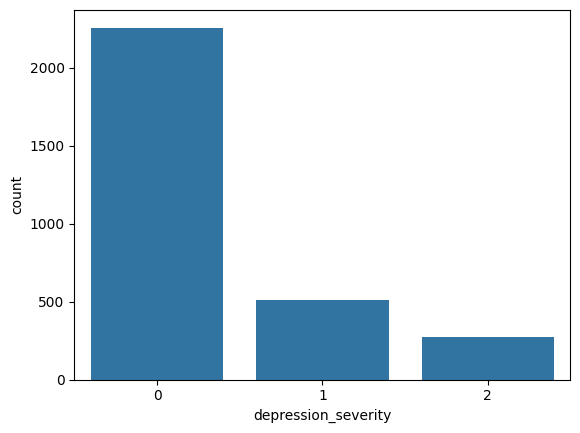

In [91]:
# what does our output variable distribution look like?
sns.countplot(x=Y_train['depression_severity'])

Pretty small distribution of non-default classes in the train set. Let's upsample classes 1 and 2.

In [92]:
ros = RandomOverSampler(sampling_strategy='not majority', random_state=7)
X_train_bal, y_train_bal = ros.fit_resample(X_train, Y_train['depression_severity'])

<Axes: xlabel='depression_severity', ylabel='count'>

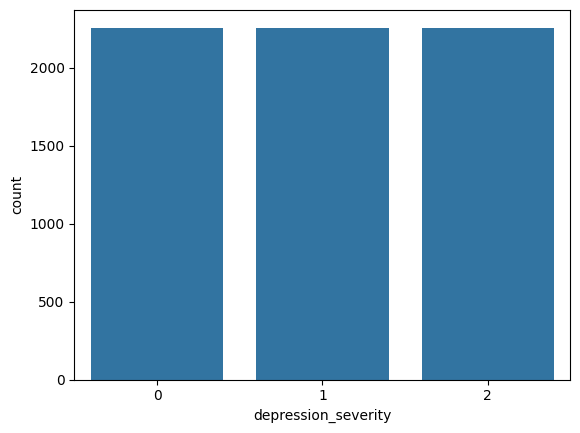

In [93]:
sns.countplot(x=y_train_bal)

In [94]:
X_train_bal.shape

(6771, 146)

In [95]:
# save to parquet

X_train_bal.to_parquet('./model_upsampled/X_train_balanced.parquet', compression='snappy')
pd.DataFrame(y_train_bal, columns=['depression_severity']).to_parquet('./model_upsampled/Y_train_balanced.parquet', compression='snappy')

### EDA

In [96]:
df = pd.concat([X_train, Y_train], axis=1)

In [97]:
df

,max_education_9-11th grade (includes 12th grade with no diploma),max_education_College graduate or above,max_education_High school graduate/GED or equivalent,max_education_Missing,max_education_Some college or AA degree,max_education_less than 9th grade,max_education_nan,marital_status_Divorced,marital_status_Living with partner,marital_status_Married,...,days_nicotine_replacement,days_hookah,days_ecigarette,hours_slept_weekday,hours_slept_weekend,recent_alcohol_use,dpq_total,depression_category,depression_binary,depression_severity
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.055462,-0.052624,-0.125735,0.260667,-0.753308,-0.079197,0.0,Minimal or no depression,False,0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,-0.055462,-0.052624,-0.125735,0.260667,-0.176540,-0.079197,0.0,Minimal or no depression,False,0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.055462,-0.052624,-0.125735,0.869289,0.111844,-0.079197,5.0,Mild depression,False,1
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.055462,-0.052624,-0.125735,-1.565201,-1.041692,15.849691,1.0,Minimal or no depression,False,0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,-0.055462,-0.052624,-0.125735,-0.956579,0.400227,-0.038196,0.0,Minimal or no depression,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3035,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.055462,-0.052624,-0.125735,-0.956579,1.553762,-0.079197,0.0,Minimal or no depression,False,0
3036,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.055462,-0.052624,-0.125735,-1.260890,1.553762,-0.079197,4.0,Minimal or no depression,False,0
3037,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.055462,-0.052624,-0.125735,0.260667,0.111844,-0.079197,4.0,Minimal or no depression,False,0
3038,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,-0.055462,-0.052624,-0.125735,-0.347956,-0.753308,-0.079197,4.0,Minimal or no depression,False,0


/var/folders/d2/vghgm_w55zd4yn2wm30cc54h0000gn/T/ipykernel_20987/3023229489.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_series.values, y=corr_series.index, palette='vlag')


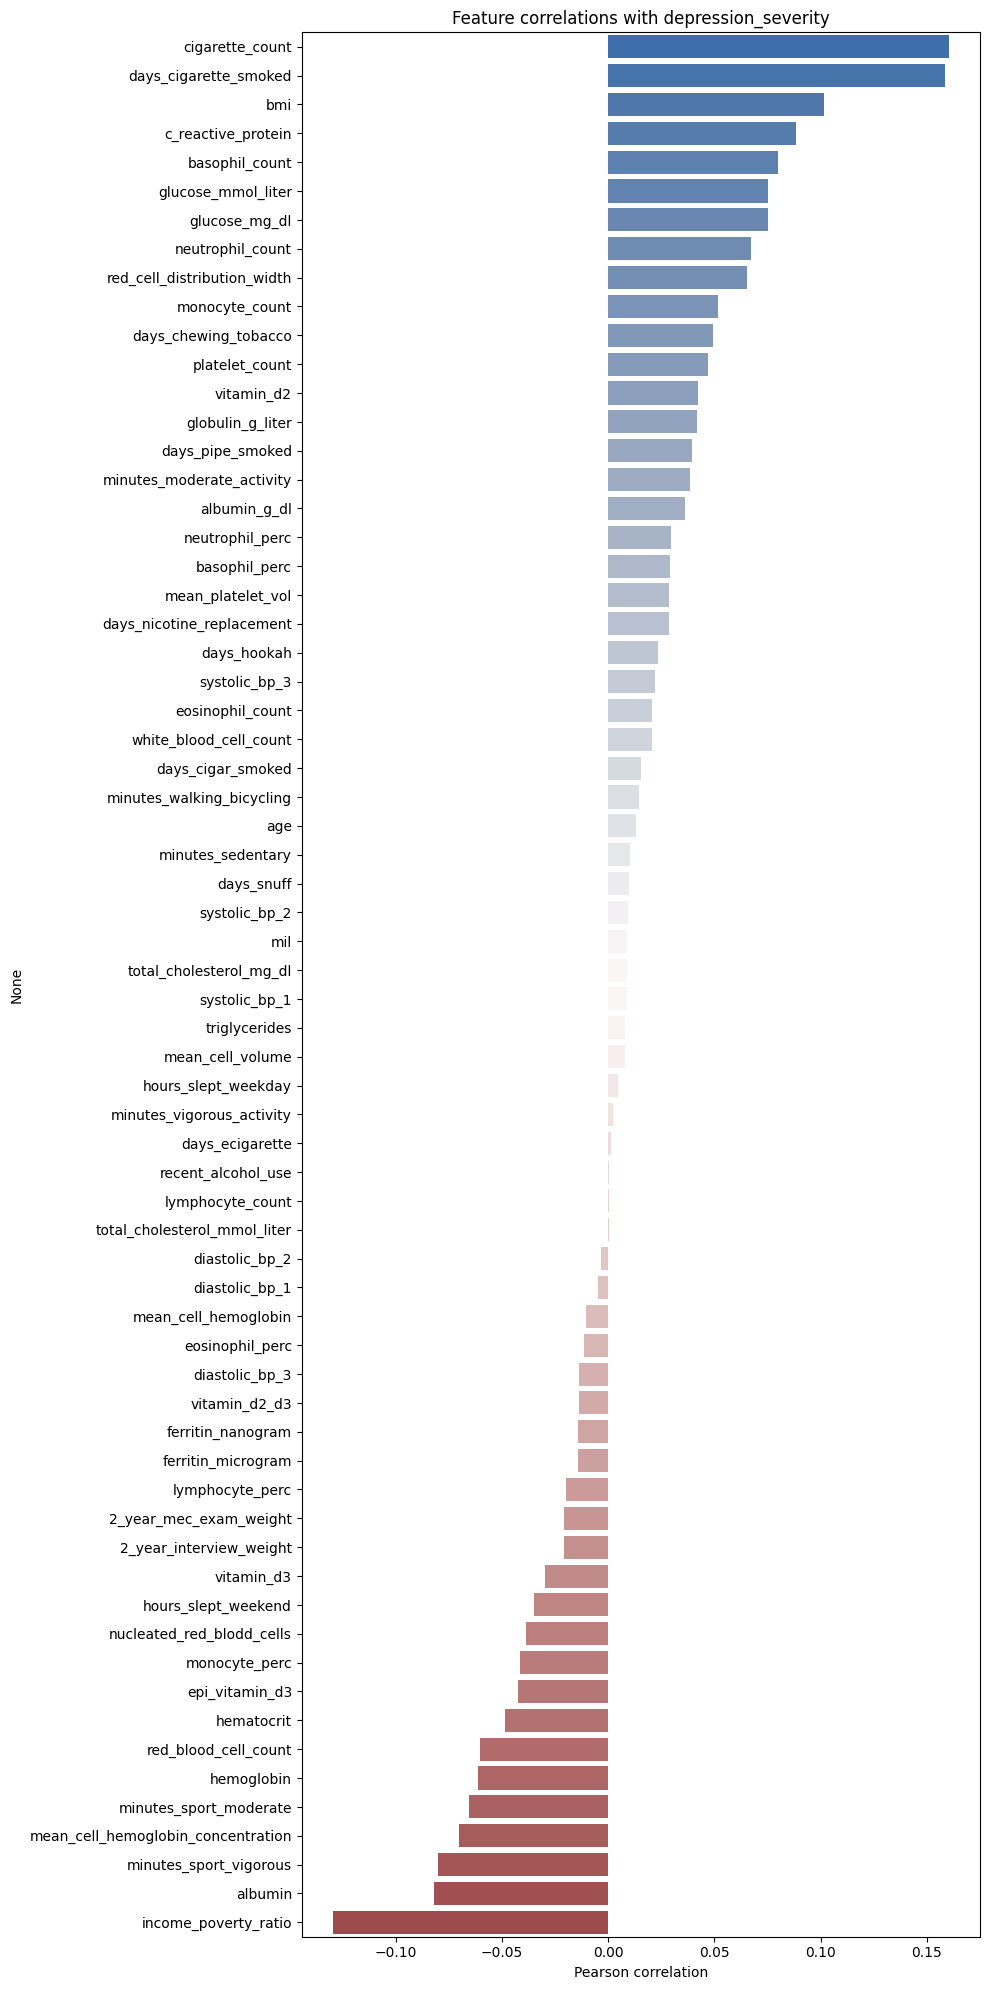

In [102]:
# put features and target together
corr_df = pd.concat([X_train[scale_cols], Y_train['depression_severity']], axis=1)

# series of correlations with the target, drop the target itself
corr_series = corr_df.corr()['depression_severity'].drop('depression_severity').sort_values(ascending=False)

# bar‑plot of the correlations
plt.figure(figsize=(10, 20))
sns.barplot(x=corr_series.values, y=corr_series.index, palette='vlag')
plt.title('Feature correlations with depression_severity')
plt.xlabel('Pearson correlation')
plt.tight_layout()
plt.show()